In [51]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [52]:
DATASET_DIRECTORY ="../Data/"

In [53]:
DF1 = pd.read_csv(os.path.join(DATASET_DIRECTORY, "Merged01.csv"))
DF2 = pd.read_csv(os.path.join(DATASET_DIRECTORY, "Merged02.csv"))


In [54]:
# Explore dataset structure
print("DF1 columns:", DF1.columns.tolist())
print("DF1 info:")
print(DF1.info())
print("\nDF2 columns:", DF2.columns.tolist())
print("DF2 info:")
print(DF2.info())


DF1 columns: ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label']
DF1 info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712311 entries, 0 to 712310
Data columns (total 40 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Header_Length    712311 non-null  float64
 1   Protocol Type    712311 non-null  int64  
 2   Time_To_Live     712311 non-null  float64
 3   Rate             712311 non-null  float64
 4   fin_flag_number  712311 non-null  float64
 5   syn_flag_number  712311 non-null  float64
 6   rst_flag_number  712311 non-null  flo

### Descrizione delle colonne del dataset
Di seguito viene fornita una breve spiegazione per ogni colonna presente nei file `Merged01.csv` e `Merged02.csv`.

- **Header_Length**: lunghezza dell'intestazione del pacchetto (in byte). Utile per analizzare overhead e frammentazione.
- **Protocol Type**: tipo di protocollo sulla rete (es. TCP, UDP). Fondamentale per distinguere i flussi di traffico.
- **Time_To_Live**: valore TTL del pacchetto, indica quanti hop può ancora percorrere. Serve per rilevare loop o tempi di vita anomali.
- **Rate**: velocità di trasmissione (pacchetti al secondo o simile). Serve per individuare picchi o Denial‑of‑Service.
- **fin_flag_number**: numero di flag FIN osservati nel traffico. Indica chiusure di connessione.
- **syn_flag_number**: numero di flag SYN, usati per l'instaurazione di connessioni TCP.
- **rst_flag_number**: numero di flag RST, segnalano reset di connessione anomali.
- **psh_flag_number**: numero di PSH (push) flag, spesso usati per trasferire dati immediatamente.
- **ack_flag_number**: numero di ACK, conferme di ricezione dei pacchetti.
- **ece_flag_number**: ECE (Explicit Congestion Notification Echo) usato per controllo congestione.
- **cwr_flag_number**: CWR (Congestion Window Reduced) usato per segnalare riduzioni della finestra.
- **ack_count**: conteggio dei pacchetti ACK nel flusso.
- **syn_count**: conteggio dei pacchetti SYN nel flusso.
- **fin_count**: conteggio dei pacchetti FIN nel flusso.
- **rst_count**: conteggio dei pacchetti RST.
- **HTTP, HTTPS, DNS, Telnet, SMTP, SSH, IRC**: indicatori binari (0/1) che segnalano se il traffico appartiene a quel servizio/applicazione. Importanti per classificare il tipo di traffico.
- **TCP, UDP**: protocollo di trasporto utilizzato. Indispensabile per distinzione tra orientato/meno orientato alla connessione.
- **DHCP, ARP, ICMP, IGMP, IPv, LLC**: altri protocolli/servizi di rete; presenti come flag binari per identificare specifiche tipologie di pacchetto.
- **Tot sum**: somma dei valori di qualche misura (probabilmente dimensioni) all'interno del flusso. Serve per valutare carichi totali.
- **Min, Max, AVG, Std**: statistiche (minimo, massimo, media, deviazione standard) di una certa metrica (es. dimensione pacchetto, interarrivo). Essenziali per captare variazioni e anomalie.
- **Tot size**: dimensione totale dei dati trasmessi nel flusso.
- **IAT**: inter-arrival time, tempo tra l'arrivo di pacchetti successivi. Utile per analisi temporale e rilevamento di attacchi a bassa frequenza.
- **Number**: numero di pacchetti nel flusso.
- **Variance**: varianza delle metriche (es. dimensioni pacchetti); indica dispersione.
- **Label**: etichetta di classe assegnata (può indicare normale/attacco o il protocollo effettivo). È la variabile target per modelli supervisionati.




In [55]:
X_columns = [
    'flow_duration', 'Header_Length', 'Protocol Type', 'Duration',
       'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count',
       'syn_count', 'fin_count', 'urg_count', 'rst_count', 
    'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP',
       'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min',
       'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue',
       'Radius', 'Covariance', 'Variance', 'Weight', 
]
y_column = 'label'

In [56]:
# Analisi Esplorativa dei Dati (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

#Distribuzione delle classi (Label) - Conta quante osservazioni per ogni classe, numero di istanze per ogni etichetta
print("Distribuzione delle classi in DF1:")
print(DF1['Label'].value_counts())
print("\nDistribuzione delle classi in DF2:")
print(DF2['Label'].value_counts())

# 2. Controllo valori mancanti - Verifica se ci sono NaN nelle colonne
print("\nValori mancanti in DF1:")
print(DF1.isnull().sum())           
print("\nValori mancanti in DF2:")
print(DF2.isnull().sum())
#Noto che in DF1 e in DF2 ci sono valori mancanti nella colonna STD.
#Essendo poche le righe con valori mancanti la soluzione più semplice è quella di eliminare queste righe.

# Analisi dei Valori Infiniti (Inf)
print("\n--- DF1: Valori Infiniti (Inf) ---")
print(np.isinf(DF1.select_dtypes(include=[np.number])).sum())

print("\n--- DF2: Valori Infiniti (Inf) ---")
print(np.isinf(DF2.select_dtypes(include=[np.number])).sum())

#I due dataset presentano dei valori infiniti nella colonna "Rate". Per gestire cio anche in questa situazione, dato che si tratta di poche righe, la soluzione più semplice è quella di eliminare queste righe.

Distribuzione delle classi in DF1:
Label
DDOS-ICMP_FLOOD            108662
DDOS-UDP_FLOOD              82011
DDOS-TCP_FLOOD              68289
DDOS-PSHACK_FLOOD           62171
DDOS-RSTFINFLOOD            61652
DDOS-SYN_FLOOD              61460
DDOS-SYNONYMOUSIP_FLOOD     54749
DOS-UDP_FLOOD               50371
DOS-TCP_FLOOD               40391
DOS-SYN_FLOOD               30620
BENIGN                      16577
MIRAI-GREETH_FLOOD          15135
MIRAI-UDPPLAIN              13342
MIRAI-GREIP_FLOOD           11187
DDOS-ICMP_FRAGMENTATION      6784
VULNERABILITYSCAN            5805
MITM-ARPSPOOFING             4590
DDOS-ACK_FRAGMENTATION       4308
DDOS-UDP_FRAGMENTATION       4264
DNS_SPOOFING                 2738
RECON-HOSTDISCOVERY          2045
RECON-OSSCAN                 1433
RECON-PORTSCAN               1251
DOS-HTTP_FLOOD               1113
DDOS-HTTP_FLOOD               416
DDOS-SLOWLORIS                354
DICTIONARYBRUTEFORCE          204
BROWSERHIJACKING               83
SQLINJE

<Axes: >

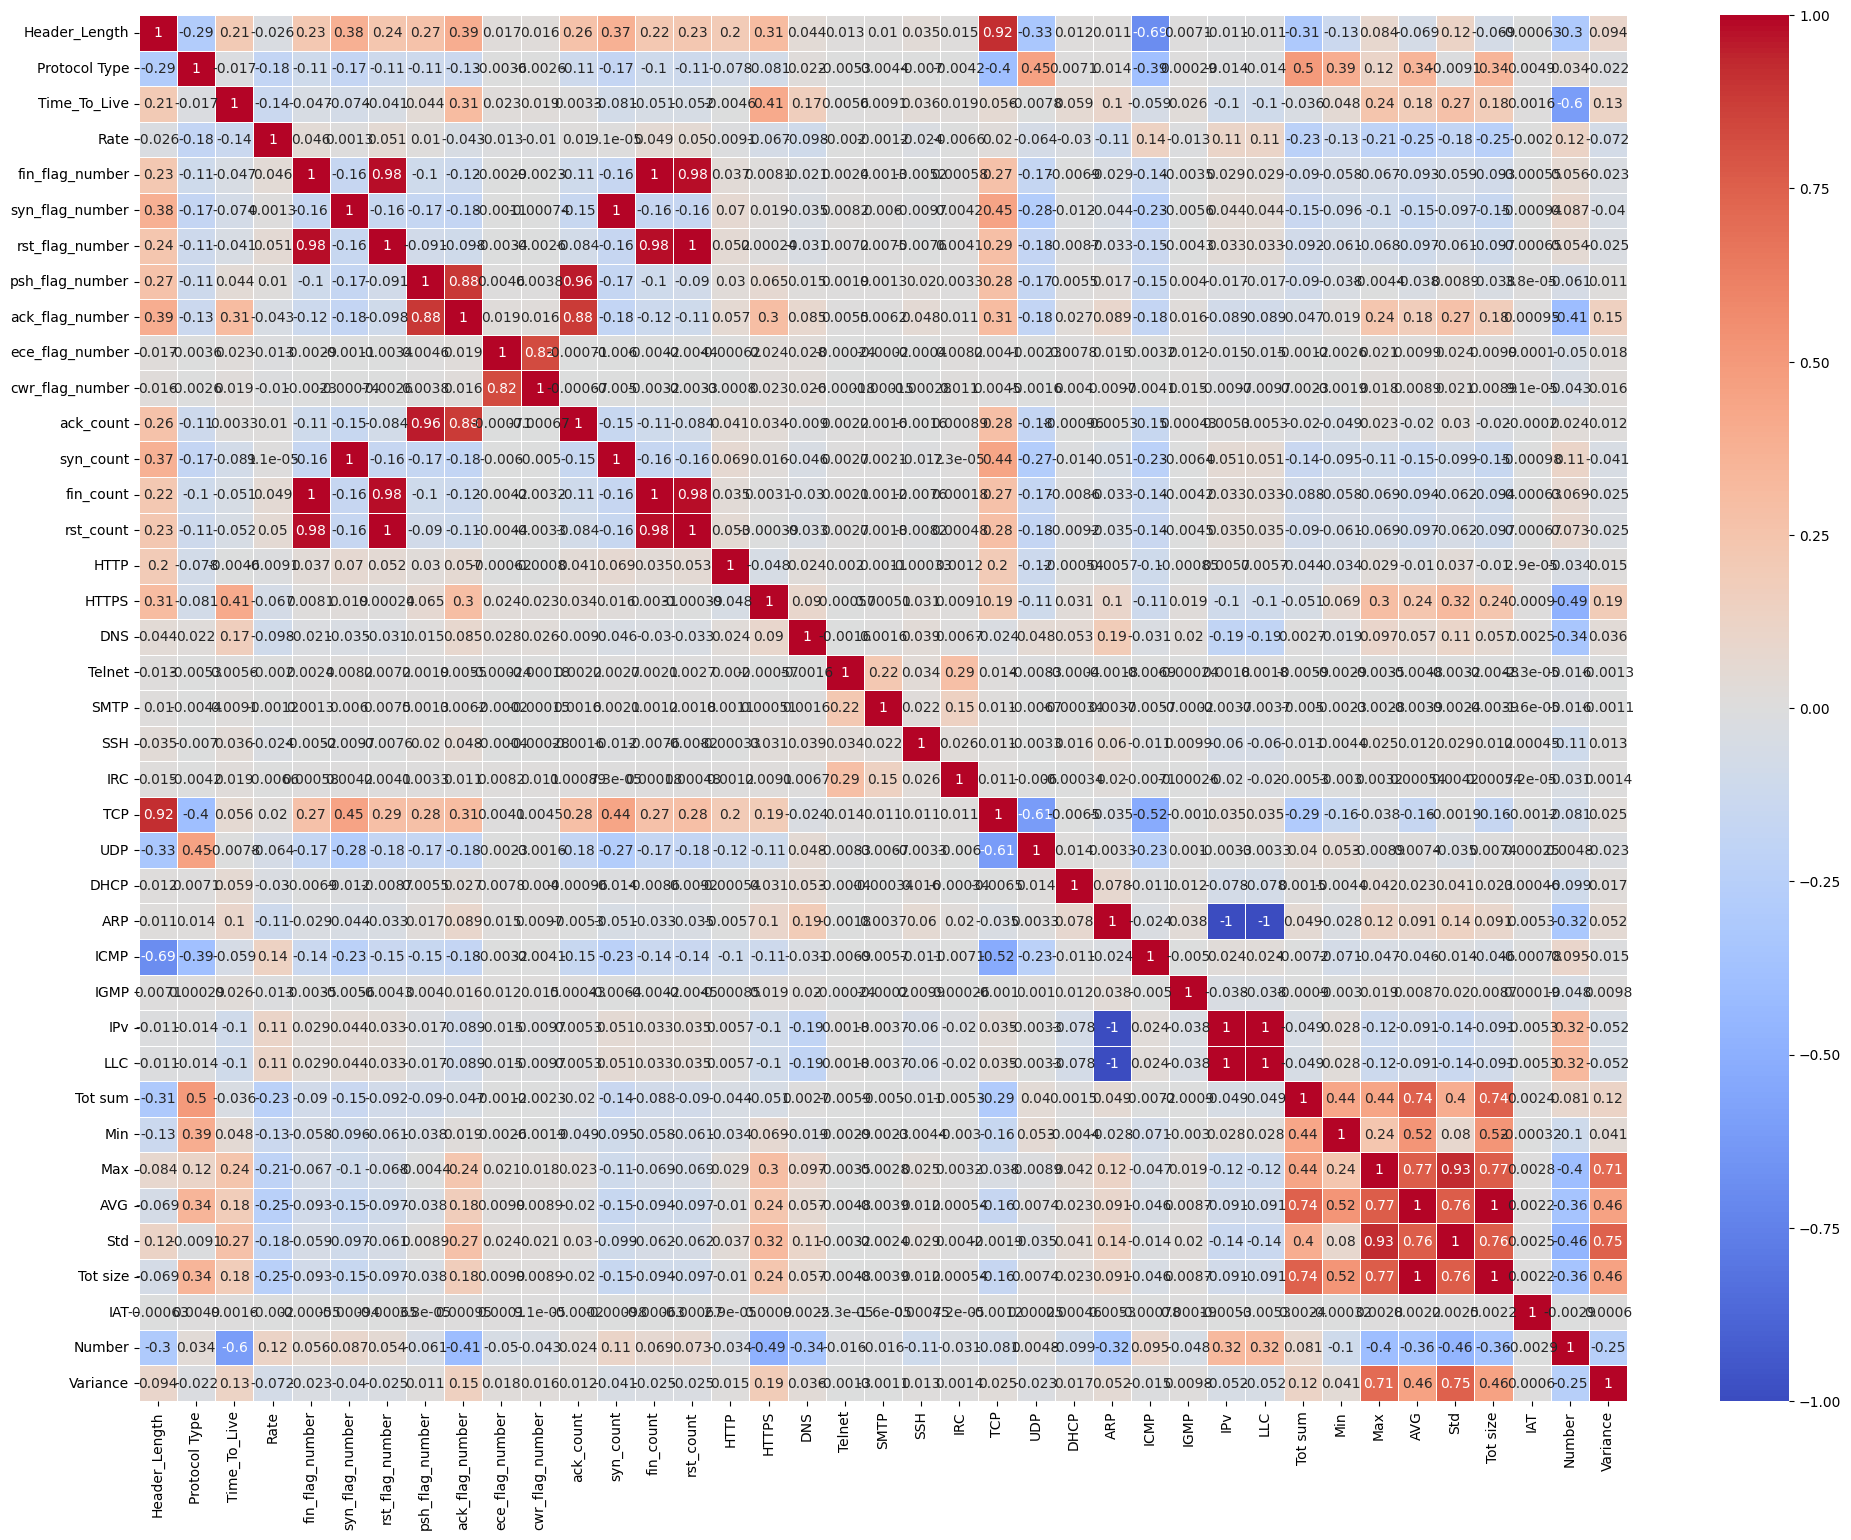

In [57]:
#Matrice di correlazione di DF1 - Analizza la correlazione tra le variabili numeriche
numeric_cols_DF1 = DF1.select_dtypes(include=[np.number])
corr_matrix_DF1 = numeric_cols_DF1.corr()
plt.figure(figsize=(24, 18))
sns.heatmap(corr_matrix_DF1, annot=True, cmap='coolwarm', linewidths=0.5,vmin=-1, vmax=1)
#Noto che:
# fin_flag_number e fin_count hanno una correlazione molto alta (1), 
# syn_flag_number e syn_count (1),
# rst_flag_number e rst_count (1),
# rst_flag_number e fin_flag_number, e di conseguenza anche rst_count e fin_count, hanno una correlazione molto alta (0.98).
# Std e Variance (1) (La varianza è letteralmente il quadrato della deviazione standard, quindi è ridondante)
# IPv e LLC (1)
# Ci sono altre correlazioni significative, ad esempio tra TCP e Header_Length (0.92), ack_count e psh_flag_number (0.96).
# Una correlazione del genere indica che le colonne sono praticamente identiche quindi probabilmente è meglio eliminarne una per evitare ridondanza e problemi di multicollinearità nei modelli di machine learning.

# ARP è inversamente proporzionale IPv e LLC (-1)
# Questo sinigfica che quando c'è ARP non c'è IPv e LLC, e viceversa.

#Data questo studio durante l'utilizzo di tale dataset verranno eliminate le colonne: rst_flag_number,Variance,LLC,ARP,fin_count, syn_count, rst_count, ack_count e Header_Length(?)

<Axes: >

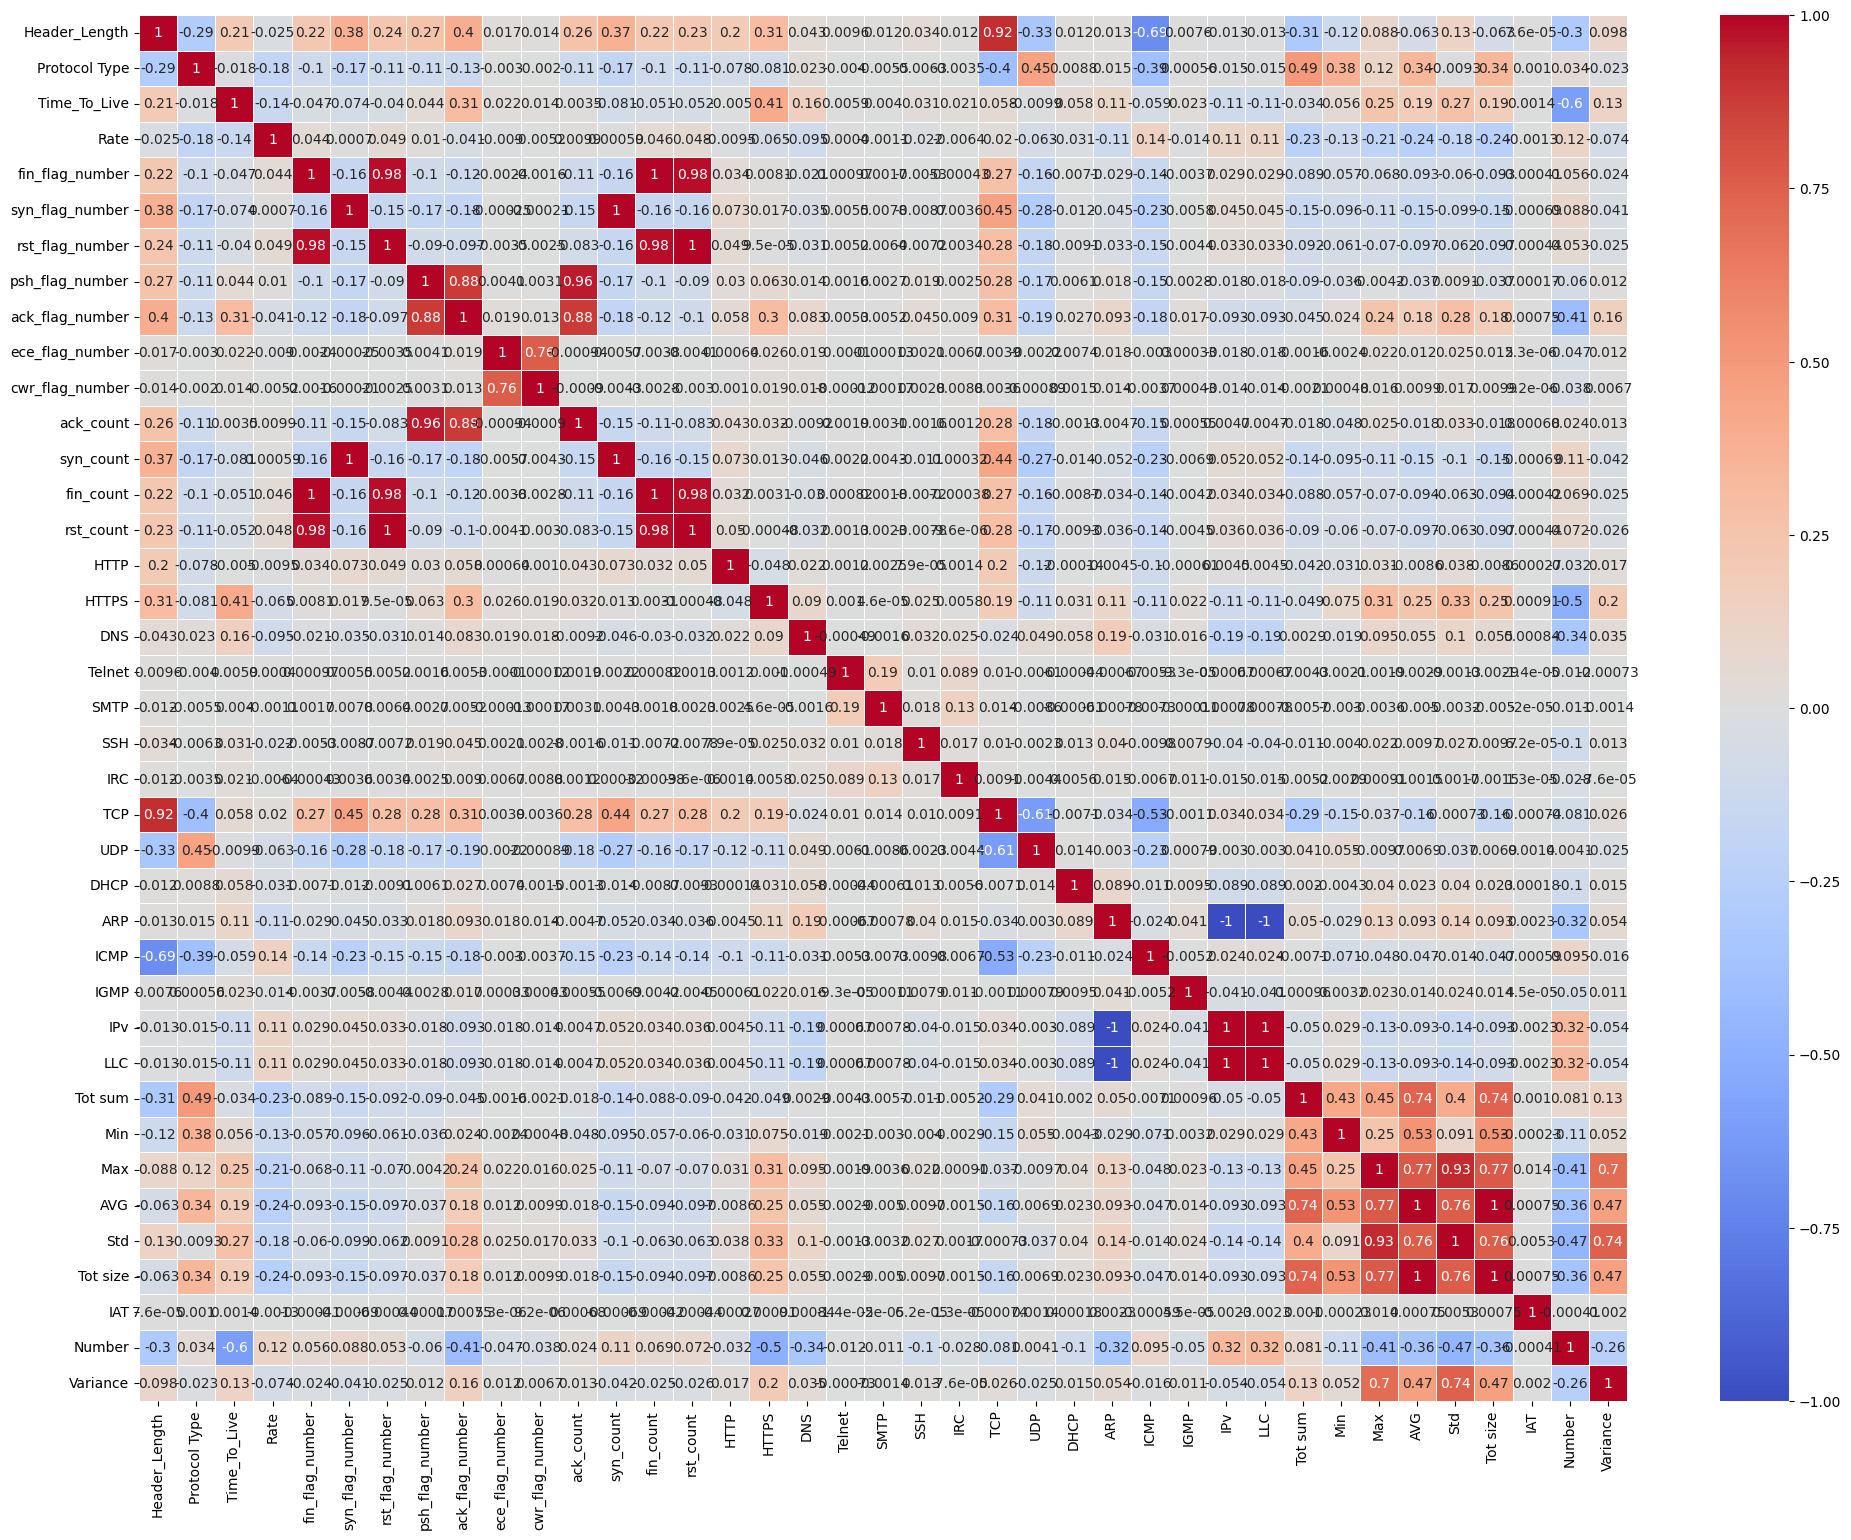

In [58]:
#Matrice di correlazione di DF2 - Analizza la correlazione tra le variabili numeriche
numeric_cols_DF2 = DF2.select_dtypes(include=[np.number])
corr_matrix_DF2 = numeric_cols_DF2.corr()
plt.figure(figsize=(24, 18))
sns.heatmap(corr_matrix_DF2, annot=True, cmap='coolwarm', linewidths=0.5,vmin=-1, vmax=1)
#Noto che:
# Lo studio fatto sul Dataset primario è valido anche per questo secondo dataset, infatti le stesse coppie di variabili mostrano una correlazione molto alta anche in questo secondo dataset.
# Concludo quindi che è possibile eliminare le stesse colonne anche in questo secondo dataset.

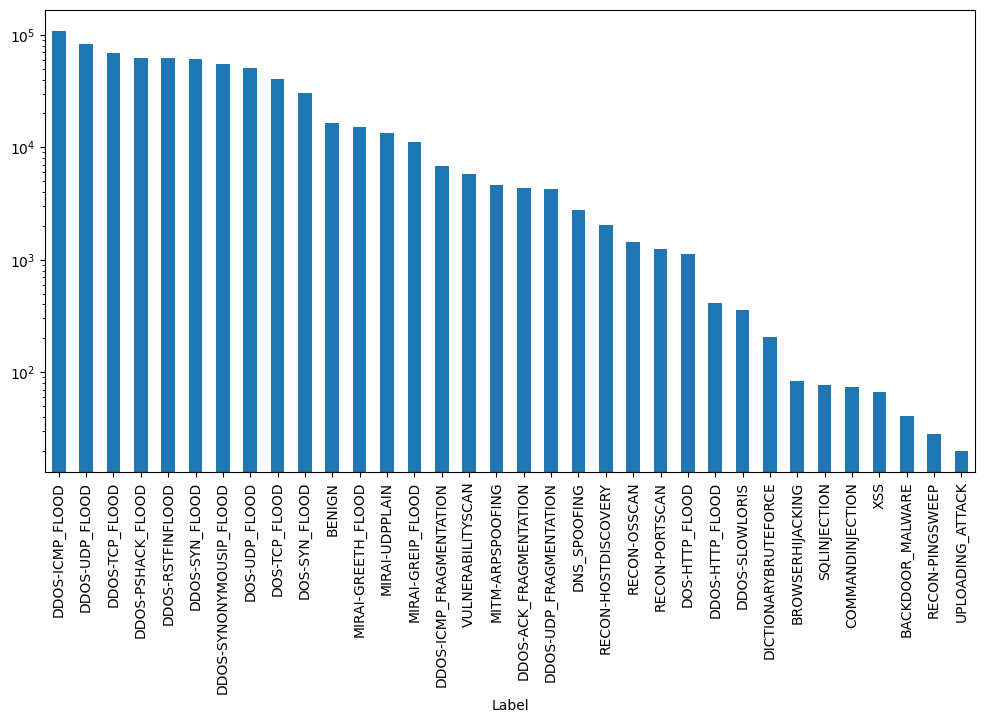

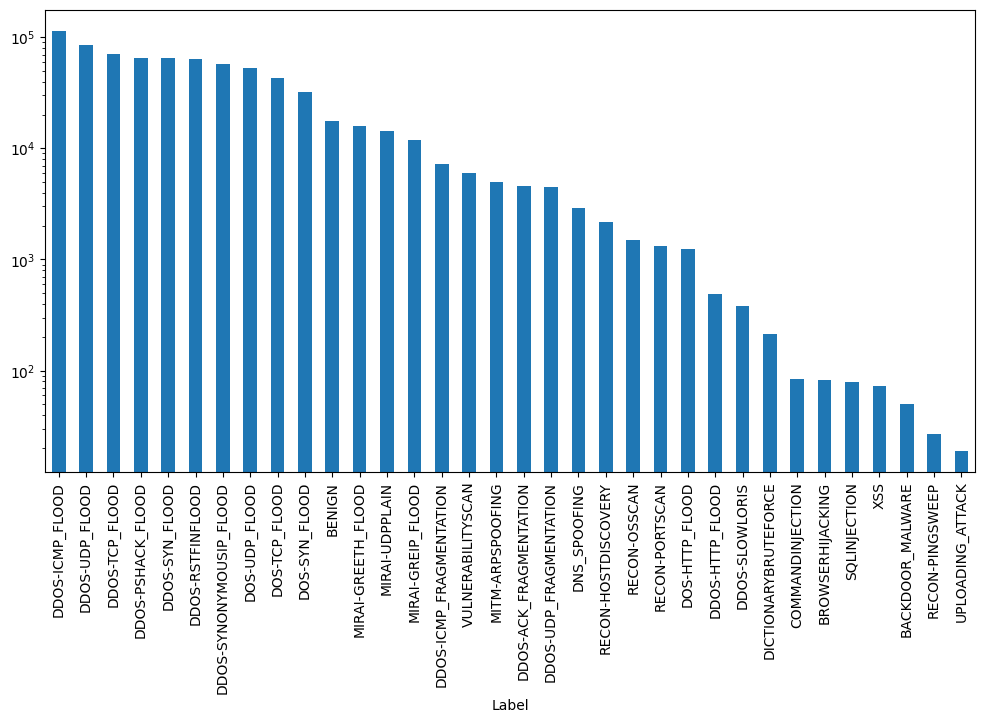

In [59]:
# Controllo un eventuale sbilanciamento delle classi
plt.figure(figsize=(12, 6))
DF1['Label'].value_counts().plot(kind='bar', logy=True)
plt.show()

plt.figure(figsize=(12, 6))
DF2['Label'].value_counts().plot(kind='bar', logy=True)
plt.show()

#Noto che in entrambi i dataset c'è uno sbilanciamento delle classi.
# In particolare vedo molti attacchi di tipo DDOS rispetto agli altri tipi, questo mi fa concludere che probabilmente il modello sarà più forte nella rilevazione di attacchi di tipo DDOS.